In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

import matplotlib.ticker as mtick
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import VECM, select_order

df = pd.read_csv("data/final_data.csv")
df['gdp_per_capita'] = df['gdp_per_capita'].fillna(0)

ELECTRICITY METHOD – PRE-ESTIMATION DIAGNOSTICS
Ukraine, 2010Q1–2021Q4  |  N = 48

 DESCRIPTIVE STATISTICS   
       electricity_consumptions   electricity       gdp_s21         gdp_2  usd_avg_q  gov_expenditure_share  unemployment_rate
count                   48.0000  4.800000e+01  4.800000e+01  4.800000e+01    48.0000                48.0000            48.0000
mean                     0.0061  2.756924e+07  1.350221e+12  6.542007e+11    18.7321                34.2559            12.3989
std                      0.0040  5.912086e+06  7.833626e+10  3.644054e+11     8.7354                 4.4291             1.1800
min                      0.0013  1.968464e+07  1.212057e+12  2.170740e+11     7.9006                21.0532            10.5335
25%                      0.0025  2.203583e+07  1.282562e+12  3.670248e+11     7.9930                32.5300            11.5631
50%                      0.0049  2.655026e+07  1.358190e+12  5.513490e+11    23.0451                34.7358            12.2222
7

/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_58699/2286822414.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series.dropna(), regression="ct", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_58699/2286822414.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series.dropna(), regression="ct", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_58699/2286822414.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series.dropna(), regression="ct", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipy


Plots saved to electricity_method_diagnostics.png 


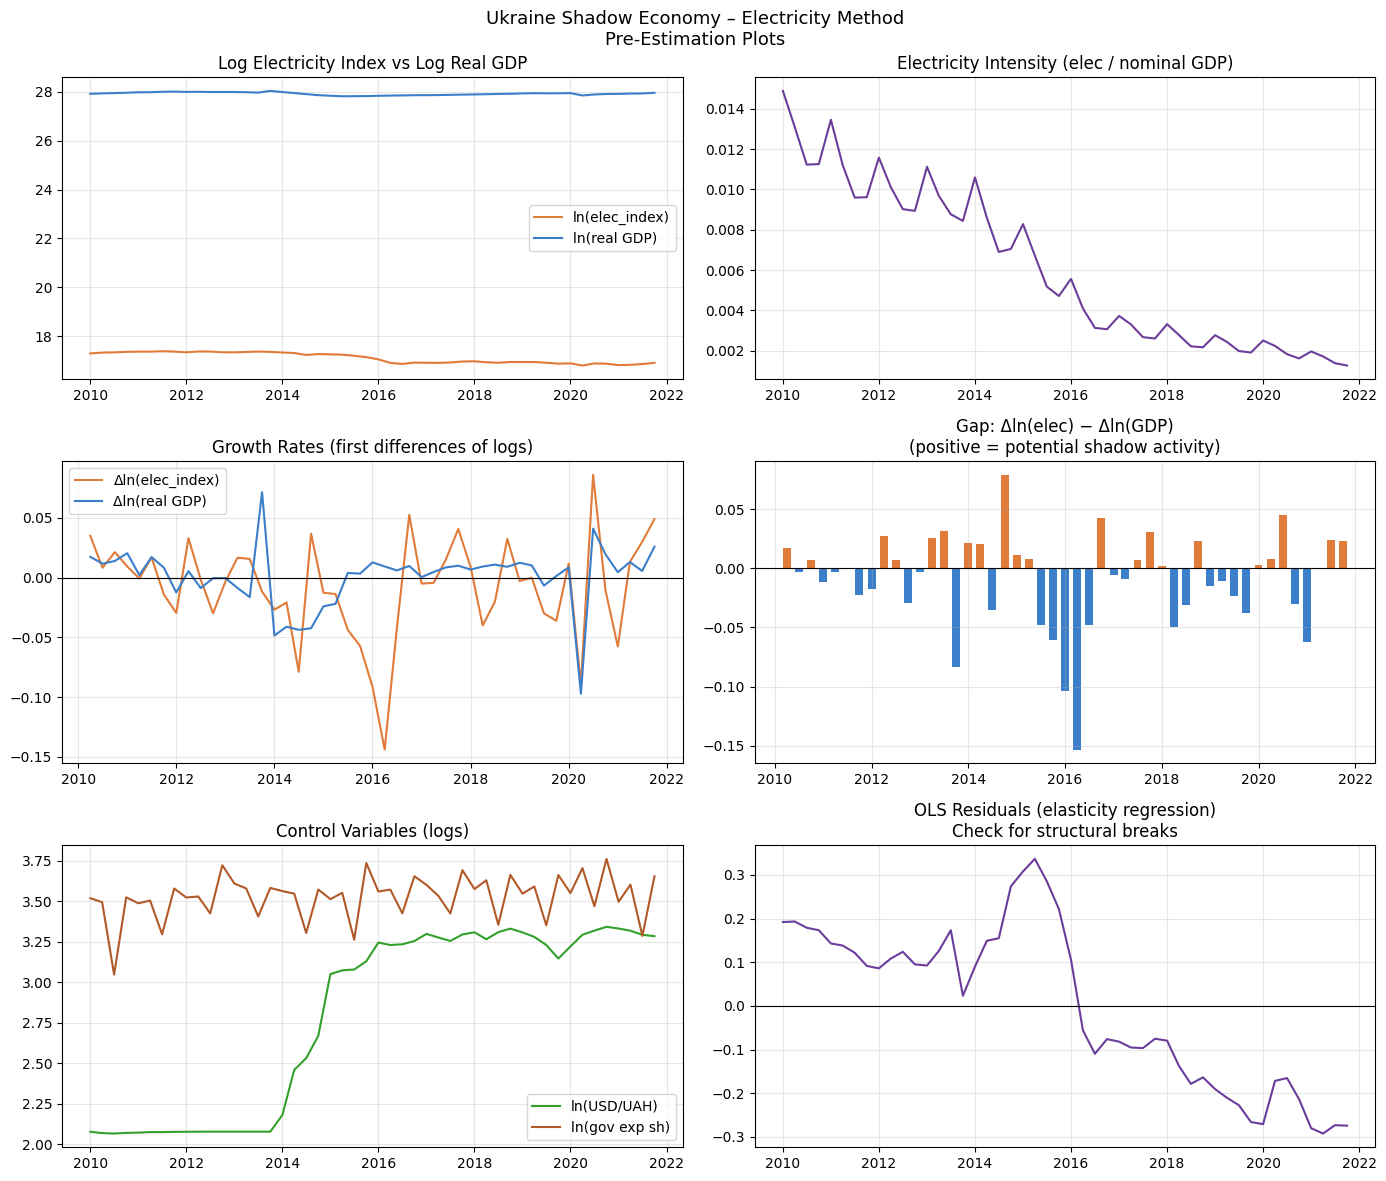

In [4]:
df["date"] = pd.PeriodIndex(df["year_quarter"], freq="Q").to_timestamp()
df = df.set_index("date").sort_index()

df["ln_elec_index"]       = np.log(df["electricity"])
df["ln_gdp_s21"]    = np.log(df["gdp_s21"])
df["ln_gdp_2"]      = np.log(df["gdp_2"])
df["ln_usd"]        = np.log(df["usd_avg_q"])
df["ln_gov_exp"]    = np.log(df["gov_expenditure_share"])
df["ln_unemp"]      = np.log(df["unemployment_rate"])
df["ln_elec_ratio"] = np.log(df["electricity_consumptions"])

 
print("ELECTRICITY METHOD – PRE-ESTIMATION DIAGNOSTICS")
print("Ukraine, 2010Q1–2021Q4  |  N =", len(df))
 

print("\n DESCRIPTIVE STATISTICS   ")
desc_cols = [
    "electricity_consumptions", "electricity", "gdp_s21", "gdp_2",
    "usd_avg_q", "gov_expenditure_share", "unemployment_rate"
]
print(df[desc_cols].describe().round(4).to_string())

print("\nSEASONAL DECOMPOSITION (additive, period=4)")
for varname, series in [("ln_elec_index", df["ln_elec_index"]),
                        ("ln_gdp_s21",    df["ln_gdp_s21"])]:
    decomp = seasonal_decompose(series, model="additive", period=4)
    seasonal_strength = decomp.seasonal.std() / (decomp.seasonal.std() + decomp.resid.dropna().std())
    print(f"  {varname}: seasonal strength = {seasonal_strength:.4f}  "
          f"(>0.64 = strong seasonality per Wang et al.)")

print("\nUNIT-ROOT TESTS ")
print("   ADF: H0 = unit root present  |  KPSS: H0 = series is stationary")
print("   Lags: AIC-selected for ADF; bandwidth auto for KPSS")
print()

ur_vars = {
    "ln_elec_index"  : df["ln_elec_index"],
    "ln_gdp_s21"     : df["ln_gdp_s21"],
    "ln_usd"         : df["ln_usd"],
    "ln_gov_exp"     : df["ln_gov_exp"],
    "ln_unemp"       : df["ln_unemp"],
    "ln_elec_ratio"  : df["ln_elec_ratio"],
}

header = f"{'Variable':<20} {'ADF stat':>10} {'ADF p':>8} {'ADF lags':>8} " \
         f"{'KPSS stat':>10} {'KPSS 5%cv':>10} {'Conclusion':>14}"
print(header)
print("-" * len(header))

ur_results = {}

for name, series in ur_vars.items():
    adf_res  = adfuller(series.dropna(), autolag="AIC", regression="ct")
    kpss_res = kpss(series.dropna(), regression="ct", nlags="auto")

    adf_stat, adf_p, adf_lags = adf_res[0], adf_res[1], adf_res[2]
    kpss_stat = kpss_res[0]
    kpss_cv5  = kpss_res[3]["5%"]

    adf_noreject  = adf_p > 0.05
    kpss_reject   = kpss_stat > kpss_cv5
    conclusion = "I(1)" if (adf_noreject and kpss_reject) else \
                 "I(0)" if (not adf_noreject and not kpss_reject) else "ambiguous"

    ur_results[name] = {"adf_p": adf_p, "conclusion": conclusion}
    print(f"  {name:<18} {adf_stat:>10.4f} {adf_p:>8.4f} {adf_lags:>8d} "
          f"{kpss_stat:>10.4f} {kpss_cv5:>10.4f} {conclusion:>14}")

print()
print("  FIRST DIFFERENCES:")
print(header)
print("-" * len(header))

for name, series in ur_vars.items():
    diff_series = series.diff().dropna()
    adf_res  = adfuller(diff_series, autolag="AIC", regression="c")
    kpss_res = kpss(diff_series, regression="c", nlags="auto")

    adf_stat, adf_p, adf_lags = adf_res[0], adf_res[1], adf_res[2]
    kpss_stat = kpss_res[0]
    kpss_cv5  = kpss_res[3]["5%"]

    adf_noreject  = adf_p > 0.05
    kpss_reject   = kpss_stat > kpss_cv5
    conclusion = "I(1)" if (adf_noreject and kpss_reject) else \
                 "I(0)" if (not adf_noreject and not kpss_reject) else "ambiguous"

    print(f"  Δ{name:<17} {adf_stat:>10.4f} {adf_p:>8.4f} {adf_lags:>8d} "
          f"{kpss_stat:>10.4f} {kpss_cv5:>10.4f} {conclusion:>14}")

print("\nENGLE–GRANGER COINTEGRATION TEST")
print("   H0: no cointegration between ln_elec_index and ln_gdp_s21")

eg_stat, eg_p, eg_cv = coint(df["ln_gdp_s21"].dropna(), df["ln_elec_index"].dropna())
print(f"   Test statistic : {eg_stat:.4f}")
print(f"   p-value        : {eg_p:.4f}")
print(f"   Critical values: 1%={eg_cv[0]:.4f}  5%={eg_cv[1]:.4f}  10%={eg_cv[2]:.4f}")
if eg_p < 0.05:
    print("   ✓ Reject H0: cointegration detected → ECM specification is appropriate")
else:
    print("   ✗ Fail to reject H0: no cointegration → use differences or VAR in differences")

print("\nJOHANSEN COINTEGRATION TEST")
print("   Variables: ln_elec_index, ln_gdp_s21, ln_usd, ln_gov_exp, ln_unemp")

joh_data = df[["ln_elec_index", "ln_gdp_s21", "ln_usd", "ln_gov_exp", "ln_unemp"]].dropna()
joh_res  = coint_johansen(joh_data, det_order=0, k_ar_diff=2)

print()
print("  Trace statistic (H0: r ≤ k):")
print(f"  {'r':>4} {'Trace stat':>12} {'CV 5%':>10} {'CV 1%':>10} {'Reject H0?':>12}")
for i in range(len(joh_res.lr1)):
    ts   = joh_res.lr1[i]
    cv5  = joh_res.cvt[i, 1]
    cv1  = joh_res.cvt[i, 0]
    rej  = "Yes" if ts > cv5 else "No"
    print(f"  {i:>4} {ts:>12.4f} {cv5:>10.4f} {cv1:>10.4f} {rej:>12}")

print()
print("  Max-eigenvalue statistic (H0: r = k):")
print(f"  {'r':>4} {'Max-eig stat':>14} {'CV 5%':>10} {'CV 1%':>10} {'Reject H0?':>12}")
for i in range(len(joh_res.lr2)):
    ms   = joh_res.lr2[i]
    cv5  = joh_res.cvm[i, 1]
    cv1  = joh_res.cvm[i, 0]
    rej  = "Yes" if ms > cv5 else "No"
    print(f"  {i:>4} {ms:>14.4f} {cv5:>10.4f} {cv1:>10.4f} {rej:>12}")

print("\nBASELINE ELECTRICITY-TO-GDP ELASTICITY (OLS in logs)")
print("   ln(elec_index) = α + β·ln(gdp_s21) + ε")
print("   β ≈ 1 supports the unit-elasticity assumption of the classic method")
print()

y = df["ln_elec_index"].dropna()
X = sm.add_constant(df["ln_gdp_s21"].loc[y.index])
ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

print()
beta = ols.params["ln_gdp_s21"]
ci   = ols.conf_int().loc["ln_gdp_s21"]
print(f"   Elasticity β = {beta:.4f}  (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")
if ci[0] <= 1.0 <= ci[1]:
    print("   ✓ Unit elasticity (β=1) is within the 95% CI → classic method assumption holds")
else:
    print("   ✗ Unit elasticity (β=1) is OUTSIDE the 95% CI → modified method is preferred")

print("\nCORRELATION MATRIX (log-level variables)")
corr_cols = ["ln_elec_index", "ln_gdp_s21", "ln_usd", "ln_gov_exp", "ln_unemp"]
print(df[corr_cols].corr().round(4).to_string())

print("\nVIF CHECK (modified model regressors)")
print("   Regressors: ln_gdp_s21, ln_usd, ln_gov_exp, ln_unemp")
print("   VIF > 10 indicates severe multicollinearity")
print()

vif_data = df[["ln_gdp_s21", "ln_usd", "ln_gov_exp", "ln_unemp"]].dropna()
vif_data_c = sm.add_constant(vif_data)
vif_df = pd.DataFrame({
    "Variable": vif_data.columns,
    "VIF": [variance_inflation_factor(vif_data_c.values, i + 1)
            for i in range(len(vif_data.columns))]
})
print(vif_df.to_string(index=False))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Ukraine Shadow Economy – Electricity Method\nPre-Estimation Plots", fontsize=13)

ax = axes[0, 0]
ax.plot(df.index, df["ln_elec_index"], label="ln(elec_index)", color="#e07b39")
ax.plot(df.index, df["ln_gdp_s21"],    label="ln(real GDP)",   color="#3b7ec9")
ax.set_title("Log Electricity Index vs Log Real GDP")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(df.index, df["electricity_consumptions"], color="#6a3d9a")
ax.set_title("Electricity Intensity (elec / nominal GDP)")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
diff_e = df["ln_elec_index"].diff()
diff_g = df["ln_gdp_s21"].diff()
ax.plot(df.index, diff_e, label="Δln(elec_index)", color="#e07b39")
ax.plot(df.index, diff_g, label="Δln(real GDP)",   color="#3b7ec9")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Growth Rates (first differences of logs)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
gap = diff_e - diff_g
ax.bar(df.index, gap, color=np.where(gap >= 0, "#e07b39", "#3b7ec9"), width=60)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Gap: Δln(elec) − Δln(GDP)\n(positive = potential shadow activity)")
ax.grid(True, alpha=0.3)

ax = axes[2, 0]
ax.plot(df.index, df["ln_usd"],     label="ln(USD/UAH)",    color="#33a02c")
ax.plot(df.index, df["ln_gov_exp"], label="ln(gov exp sh)", color="#b15928")
ax.set_title("Control Variables (logs)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2, 1]
resid = ols.resid
ax.plot(df.loc[resid.index].index, resid, color="#6a3d9a")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("OLS Residuals (elasticity regression)\nCheck for structural breaks")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/electricity_method_diagnostics.png", dpi=150, bbox_inches="tight")
print("\nPlots saved to electricity_method_diagnostics.png ")

VECM ESTIMATION – ELECTRICITY METHOD
Ukraine 2010Q1–2021Q4

LAG ORDER SELECTION (VAR in levels) 
 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -28.47      -26.80   4.431e-13      -27.86
1      -28.69      -25.97   3.885e-13      -27.70
2      -29.27      -25.51   2.664e-13      -27.90
3      -29.54      -24.73   3.090e-13      -27.79
4      -30.46      -24.61   2.690e-13      -28.33
5      -34.56      -27.66   2.124e-14      -32.05
6     -45.58*     -37.63*  1.924e-17*     -42.68*
-------------------------------------------------

  AIC-selected lag order (k): 6
  VECM will use k_ar_diff = 5  (lags of differences)

VECM ESTIMATION (r=2, deterministic trend in CI)
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_elec
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-

  ✓ Chart saved to shadow_economy_sensitivity.png

ANCHOR SENSITIVITY SUMMARY 
  Range of estimates by year (min → max across anchors):

  Year        Min      Max   Spread
  ----------------------------------
  2010      19.7%    59.5%    39.8pp
  2011      19.9%    59.6%    39.7pp
  2012      22.8%    61.0%    38.2pp
  2013      24.1%    61.7%    37.6pp
  2014      20.6%    59.9%    39.3pp
  2015      29.3%    64.3%    35.0pp
  2016      17.5%    58.4%    40.9pp
  2017      18.9%    59.1%    40.2pp
  2018      19.2%    59.2%    40.0pp
  2019      12.7%    55.9%    43.2pp
  2020      13.6%    56.4%    42.8pp
  2021       4.2%    51.6%    47.5pp


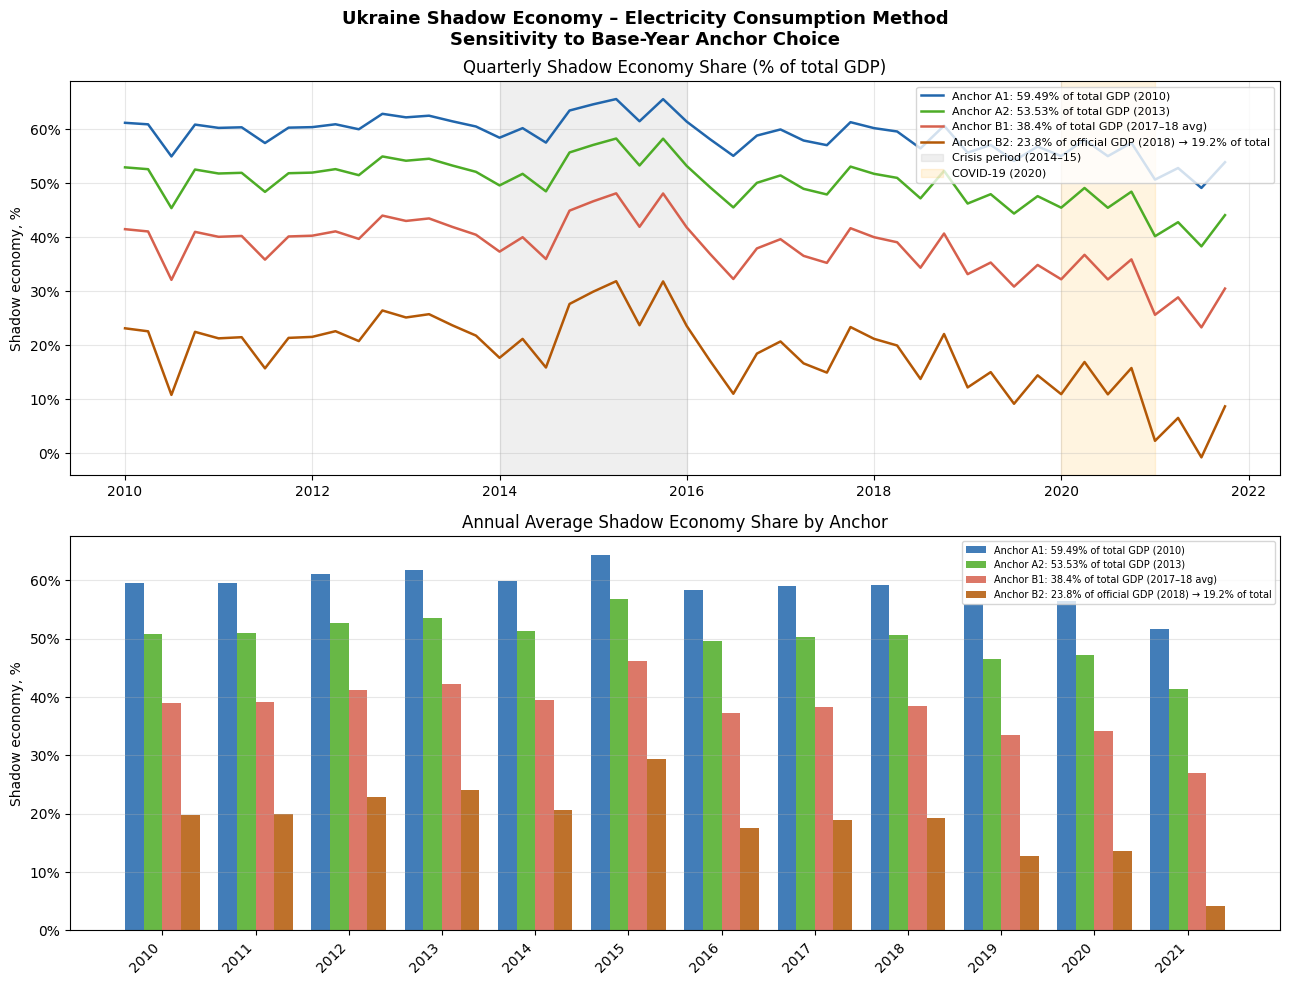

In [5]:
df = pd.read_csv("data/final_data.csv")

df["date"] = pd.PeriodIndex(df["year_quarter"], freq="Q").to_timestamp()
df = df.set_index("date").sort_index()

df["ln_elec"]    = np.log(df["electricity"])
df["ln_gdp"]     = np.log(df["gdp_s21"])
df["ln_usd"]     = np.log(df["usd_avg_q"])
df["ln_gov_exp"] = np.log(df["gov_expenditure_share"])
df["ln_unemp"]   = np.log(df["unemployment_rate"])

for q in [2, 3, 4]:
    df[f"Q{q}"] = (df.index.quarter == q).astype(int)

 
print("VECM ESTIMATION – ELECTRICITY METHOD")
print("Ukraine 2010Q1–2021Q4")
 
 
vecm_vars = ["ln_elec", "ln_gdp", "ln_usd", "ln_gov_exp", "ln_unemp"]
data_vecm  = df[vecm_vars].dropna()
 
print("\nLAG ORDER SELECTION (VAR in levels) ")
lag_sel = select_order(data_vecm, maxlags=6, deterministic="colo")
print(lag_sel.summary())
best_lag = lag_sel.aic
print(f"\n  AIC-selected lag order (k): {best_lag}")
print(f"  VECM will use k_ar_diff = {best_lag - 1}  (lags of differences)")
 
k_ar_diff = max(best_lag - 1, 1)

print("\nVECM ESTIMATION (r=2, deterministic trend in CI)")
 
exog = df[["Q2", "Q3", "Q4"]].loc[data_vecm.index]
 
vecm_fit = VECM(
    data_vecm,
    k_ar_diff   = k_ar_diff,
    coint_rank  = 2,
    deterministic = "colo",
    exog        = exog
).fit()
 
print(vecm_fit.summary())
 
print("\nCOINTEGRATING VECTORS (β) ")
beta = vecm_fit.beta
print(f"\n  β matrix (columns = cointegrating vectors):")
beta_df = pd.DataFrame(beta, index=vecm_vars, columns=["CV1", "CV2"])
print(beta_df.round(6).to_string())
 
print("\nRECONSTRUCTING ELECTRICITY-IMPLIED GDP")
b = vecm_fit.beta

b2_usd  = b[2, 1]
b2_gov  = b[3, 1]
b2_unemp= b[4, 1]
 
b1_usd  = b[2, 0]
b1_gov  = b[3, 0]
b1_unemp= b[4, 0]
 
data_full = df[vecm_vars].dropna()

elec_LR = (-b1_usd  * data_full["ln_usd"]
           -b1_gov  * data_full["ln_gov_exp"]
           -b1_unemp* data_full["ln_unemp"])

elec_LR = elec_LR + (data_full["ln_elec"].mean() - elec_LR.mean())
 

gdp_LR  = (-b2_usd  * data_full["ln_usd"]
           -b2_gov  * data_full["ln_gov_exp"]
           -b2_unemp* data_full["ln_unemp"])
gdp_LR  = gdp_LR + (data_full["ln_gdp"].mean() - gdp_LR.mean())
 


elec_gap = data_full["ln_elec"] - elec_LR

y_e = data_full["ln_elec"]
X_e = sm.add_constant(data_full["ln_gdp"])
ols_elast = sm.OLS(y_e, X_e).fit()
elasticity = ols_elast.params["ln_gdp"]
print(f"  Electricity-GDP elasticity used for scaling: {elasticity:.4f}")

ln_gdp_implied_series = gdp_LR + elec_gap / elasticity
gdp_implied = np.exp(ln_gdp_implied_series)
actual_gdp  = np.exp(data_full["ln_gdp"])
 
common_idx  = gdp_implied.index
print(f"  Series starts: {common_idx[0].strftime('%Y Q')}{common_idx[0].quarter}")
print(f"  Series ends  : {common_idx[-1].strftime('%Y Q')}{common_idx[-1].quarter}")
print(f"  Observations : {len(common_idx)}")
 
print("\n  Implied vs Official GDP (levels check, first 8 rows):")
check = pd.DataFrame({
    "official_gdp"  : actual_gdp.iloc[:8].values,
    "implied_gdp"   : gdp_implied.iloc[:8].values,
    "ratio_imp/off" : (gdp_implied / actual_gdp).iloc[:8].values
}, index=common_idx[:8])
print(check.round(2).to_string())

idx_implied  = gdp_implied  / gdp_implied.iloc[0]
idx_official = actual_gdp   / actual_gdp.iloc[0]

print("\nSHADOW ECONOMY SHARES UNDER FOUR ANCHORS ")
 
def annual_avg_index(series, year):
    """Mean of quarterly index values in a given calendar year."""
    return series[series.index.year == year].mean()
 
def shadow_series(idx_off, idx_imp, base_frac_total, ref_year, ref_quarters=None):
    """
    Compute quarterly shadow share (% of total GDP).
    base_frac_total : shadow / total_GDP at reference period (decimal)
    ref_year        : year to anchor (uses annual average of that year)
    ref_quarters    : if not None, list of specific quarters to average (e.g. [2017,2018])
    """
    ratio = idx_off / idx_imp
 
    if ref_quarters is None:
        ref_ratio = annual_avg_index(ratio, ref_year)
    else:
        ref_ratio = np.mean([annual_avg_index(ratio, y) for y in ref_quarters])

    scale = (1 - base_frac_total) / ref_ratio
    shadow = 1 - ratio * scale
    return shadow * 100

anchors = {
    "A1_2010_59.49pct_total": dict(
        base_frac_total = 0.5949,
        ref_year        = 2010,
        ref_quarters    = None,
        label           = "Anchor A1: 59.49% of total GDP (2010)",
        color           = "#2166ac",
        note            = "Group A source"
    ),
    "A2_2013_53.53pct_total": dict(
        base_frac_total = 0.5353,
        ref_year        = 2013,
        ref_quarters    = None,
        label           = "Anchor A2: 53.53% of total GDP (2013)",
        color           = "#4dac26",
        note            = "Group A source"
    ),
    "B1_2017_18_38.4pct_total": dict(
        base_frac_total = 0.384,
        ref_year        = None,
        ref_quarters    = [2017, 2018],
        label           = "Anchor B1: 38.4% of total GDP (2017–18 avg)",
        color           = "#d6604d",
        note            = "Group B source"
    ),
    "B2_2018_23.8pct_official": dict(
        base_frac_total = 0.238 / (1 + 0.238),
        ref_year        = 2018,
        ref_quarters    = None,
        label           = "Anchor B2: 23.8% of official GDP (2018) → {:.1f}% of total".format(
                              0.238 / (1 + 0.238) * 100),
        color           = "#b35806",
        note            = "Group B source – narrower definition"
    ),
}
 
results = {}
for key, cfg in anchors.items():
    s = shadow_series(
        idx_official, idx_implied,
        cfg["base_frac_total"],
        cfg.get("ref_year"),
        cfg.get("ref_quarters")
    )
    results[key] = s
    print(f"\n  {cfg['label']}  [{cfg['note']}]")
    print(f"  {'Quarter':<10} {'Shadow %':>10}   |   Annual averages:")
    ann = s.groupby(s.index.year).mean()
    for yr, val in ann.items():
        print(f"  {yr}            {val:>8.2f}%")

print("\nANNUAL COMPARISON TABLE")
ann_dict = {}
for key, s in results.items():
    ann_dict[anchors[key]["label"]] = s.groupby(s.index.year).mean().round(2)
 
summary = pd.DataFrame(ann_dict)
summary.index.name = "Year"
print(summary.to_string())

quarterly_df = pd.DataFrame({
    "quarter"                     : common_idx.strftime("%YQ") + \
                                    common_idx.quarter.astype(str),
    "gdp_official_real"           : actual_gdp.values,
    "gdp_implied_total"           : gdp_implied.values,
})
for key, s in results.items():
    quarterly_df[key] = s.values
 
quarterly_df.to_csv("outputs/shadow_economy_electricity.csv", index=False)
print("\n  ✓ Quarterly results saved to shadow_economy_electricity.csv")

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle(
    "Ukraine Shadow Economy – Electricity Consumption Method\n"
    "Sensitivity to Base-Year Anchor Choice",
    fontsize=13, fontweight="bold"
)

ax = axes[0]
for key, cfg in anchors.items():
    ax.plot(common_idx, results[key],
            label=cfg["label"], color=cfg["color"], linewidth=1.8)

ax.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2016-01-01"),
           alpha=0.12, color="grey", label="Crisis period (2014–15)")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-01-01"),
           alpha=0.12, color="orange", label="COVID-19 (2020)")
 
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Quarterly Shadow Economy Share (% of total GDP)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylabel("Shadow economy, %")

ax2 = axes[1]
ann_df = summary.copy()
years  = ann_df.index.tolist()
x      = np.arange(len(years))
width  = 0.2
colors = [cfg["color"] for cfg in anchors.values()]
labels = [cfg["label"] for cfg in anchors.values()]
 
for i, (col, color, label) in enumerate(zip(ann_df.columns, colors, labels)):
    ax2.bar(x + i * width, ann_df[col], width, label=label, color=color, alpha=0.85)
 
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(years, rotation=45, ha="right")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_title("Annual Average Shadow Economy Share by Anchor")
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylabel("Shadow economy, %")
 
plt.tight_layout()
plt.savefig("outputs/shadow_economy_sensitivity.png", dpi=150, bbox_inches="tight")
print("  ✓ Chart saved to shadow_economy_sensitivity.png")

print("\nANCHOR SENSITIVITY SUMMARY ")
print("  Range of estimates by year (min → max across anchors):\n")
print(f"  {'Year':<6} {'Min':>8} {'Max':>8} {'Spread':>8}")
print("  " + "-" * 34)
for yr in summary.index:
    row  = summary.loc[yr]
    print(f"  {yr:<6} {row.min():>7.1f}% {row.max():>7.1f}% {row.max()-row.min():>7.1f}pp")